# Data

- https://data.4tu.nl/articles/_/12694403/1
- https://research.tudelft.nl/en/datasets/loophole-free-bell-inequality-violation-using-electron-spins-sepa/

next is

- https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.115.250402


--- Bell Test Results ---
Total Trials: 245
CHSH S (Total): 2.422 ± 0.204
--- X-Theta Analysis ---
S (Clockwise): 1.866 ± 0.416 (N=70)
S (C-Clockwise): 3.047 ± 0.380 (N=50)
Delta S (Observed): -1.182
Permutation p-value: 0.0500


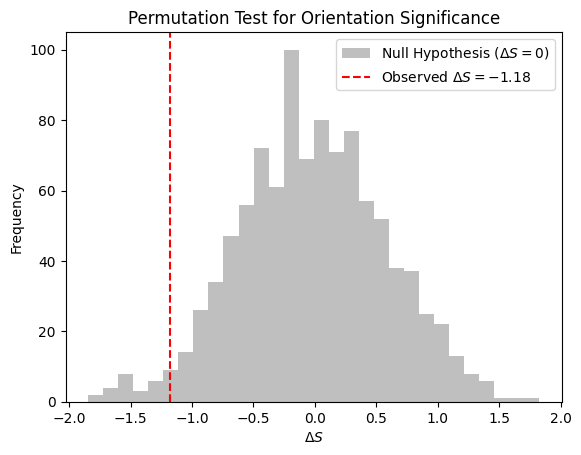

In [ ]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ==========================================
# 1. SETUP & DATA EXTRACTION
# ==========================================
zip_path = "data.zip"
extract_dir = "bell_data_extracted"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

data_filepath = os.path.join(extract_dir, "bell_open_data.txt")

# ==========================================
# 2. DATA LOADING (Source: )
# ==========================================
# Load raw data columns
data = np.loadtxt(
    data_filepath, delimiter=",", skiprows=0, usecols=np.arange(1, 17), dtype=np.int64
)

# Map columns to variables
event_ready_click1_time = data[:, 2]
event_ready_click1_channel = data[:, 3]
event_ready_click2_time = data[:, 4]
event_ready_click2_channel = data[:, 5]
random_number_A = data[:, 6]
random_number_B = data[:, 7]
readout_click_A_time = data[:, 10]
readout_click_B_time = data[:, 11]
click_after_excite_A_time = data[:, 12]
click_after_excite_B_time = data[:, 13]
last_invalid_marker_A = data[:, 14]
last_invalid_marker_B = data[:, 15]

# ==========================================
# 3. FULL FILTERING LOGIC (Source: )
# ==========================================
event_ready_window_start_channel0 = 5426350
event_ready_window_start_channel1 = 5425700
event_ready_window_length = 52450
event_ready_window_separation = 250000
readout_window_start = 10620
readout_window_length = 3700
check_for_invalid_marker_in_past = 250

# Heralding Filters
filter_w1_ch0 = (
    (event_ready_window_start_channel0 <= event_ready_click1_time)
    & (
        event_ready_click1_time
        < (event_ready_window_start_channel0 + event_ready_window_length)
    )
    & (event_ready_click1_channel == 0)
)
filter_w1_ch1 = (
    (event_ready_window_start_channel1 <= event_ready_click1_time)
    & (
        event_ready_click1_time
        < (event_ready_window_start_channel1 + event_ready_window_length)
    )
    & (event_ready_click1_channel == 1)
)
w1_filter = filter_w1_ch0 | filter_w1_ch1

filter_w2_ch0 = (
    (
        event_ready_window_start_channel0 + event_ready_window_separation
        <= event_ready_click2_time
    )
    & (
        event_ready_click2_time
        < (
            event_ready_window_start_channel0
            + event_ready_window_separation
            + event_ready_window_length
        )
    )
    & (event_ready_click2_channel == 0)
)
filter_w2_ch1 = (
    (
        event_ready_window_start_channel1 + event_ready_window_separation
        <= event_ready_click2_time
    )
    & (
        event_ready_click2_time
        < (
            event_ready_window_start_channel1
            + event_ready_window_separation
            + event_ready_window_length
        )
    )
    & (event_ready_click2_channel == 1)
)
w2_filter = filter_w2_ch0 | filter_w2_ch1

psi_min_filter = event_ready_click1_channel != event_ready_click2_channel
ready_filter = w1_filter & w2_filter & psi_min_filter

# Signal Integrity Filters
no_invalid_marker = (
    (last_invalid_marker_A == 0)
    | (last_invalid_marker_A > check_for_invalid_marker_in_past)
) & (
    (last_invalid_marker_B == 0)
    | (last_invalid_marker_B > check_for_invalid_marker_in_past)
)
no_excitation = (click_after_excite_A_time == 0) & (click_after_excite_B_time == 0)

# Final Bell Trial Mask
bell_trial_filter = ready_filter & no_invalid_marker & no_excitation

# ==========================================
# 4. STATISTICAL ANALYSIS CORE
# ==========================================
a_i = random_number_A
b_i = random_number_B
det_A = (readout_click_A_time > readout_window_start) & (
    readout_click_A_time <= readout_window_start + readout_window_length
)
det_B = (readout_click_B_time > readout_window_start) & (
    readout_click_B_time <= readout_window_start + readout_window_length
)
x_i = det_A.astype(int) * 2 - 1
y_i = det_B.astype(int) * 2 - 1


def calculate_s_param(mask):
    """Calculates S, S_error, and component correlations E_ab."""
    inputs = [[0, 0], [0, 1], [1, 0], [1, 1]]
    e_vals = np.zeros(4)
    e_errs = np.zeros(4)
    for i, (a, b) in enumerate(inputs):
        m = mask & (a_i == a) & (b_i == b)
        n = np.sum(m)
        if n == 0:
            continue
        e_vals[i] = np.sum(x_i[m] * y_i[m]) / n
        e_errs[i] = np.sqrt((1 - e_vals[i] ** 2) / n)
    S = e_vals[0] + e_vals[1] + e_vals[2] - e_vals[3]
    S_err = np.sqrt(np.sum(e_errs**2))
    return S, S_err


# ==========================================
# 5. X-THETA (ORIENTATION) ANALYSIS
# ==========================================
valid_idx = np.where(bell_trial_filter)[0]
v = list(zip(a_i[valid_idx], b_i[valid_idx]))

# Transitions
cw_t = [((0, 0), (0, 1)), ((0, 1), (1, 1)), ((1, 1), (1, 0)), ((1, 0), (0, 0))]
ccw_t = [((0, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (0, 1)), ((0, 1), (0, 0))]

cw_mask, ccw_mask = np.zeros_like(bell_trial_filter), np.zeros_like(bell_trial_filter)
for k in range(1, len(v)):
    if (v[k - 1], v[k]) in cw_t:
        cw_mask[valid_idx[k]] = True
    if (v[k - 1], v[k]) in ccw_t:
        ccw_mask[valid_idx[k]] = True

S_total, Serr_total = calculate_s_param(bell_trial_filter)
S_cw, Serr_cw = calculate_s_param(cw_mask)
S_ccw, Serr_ccw = calculate_s_param(ccw_mask)
obs_delta_s = S_cw - S_ccw

# ==========================================
# 6. PERMUTATION TEST (AI/ML RIGOR)
# ==========================================
# Does the order actually matter, or is this noise?
n_permutations = 1000
null_delta_s = []
for _ in range(n_permutations):
    shuffled_idx = np.random.permutation(valid_idx)
    # Re-evaluate masks based on shuffled sequence
    v_shuff = list(zip(a_i[shuffled_idx], b_i[shuffled_idx]))
    m1, m2 = np.zeros_like(bell_trial_filter), np.zeros_like(bell_trial_filter)
    for k in range(1, len(v_shuff)):
        if (v_shuff[k - 1], v_shuff[k]) in cw_t:
            m1[shuffled_idx[k]] = True
        if (v_shuff[k - 1], v_shuff[k]) in ccw_t:
            m2[shuffled_idx[k]] = True
    s1, _ = calculate_s_param(m1)
    s2, _ = calculate_s_param(m2)
    null_delta_s.append(s1 - s2)

p_val = np.mean(np.abs(null_delta_s) >= np.abs(obs_delta_s))

# ==========================================
# 7. RESULTS & PLOTTING
# ==========================================
print(f"--- Bell Test Results ---")
print(f"Total Trials: {len(valid_idx)}")
print(f"CHSH S (Total): {S_total:.3f} ± {Serr_total:.3f}")
print(f"--- X-Theta Analysis ---")
print(f"S (Clockwise): {S_cw:.3f} ± {Serr_cw:.3f} (N={np.sum(cw_mask)})")
print(f"S (C-Clockwise): {S_ccw:.3f} ± {Serr_ccw:.3f} (N={np.sum(ccw_mask)})")
print(f"Delta S (Observed): {obs_delta_s:.3f}")
print(f"Permutation p-value: {p_val:.4f}")

plt.hist(
    null_delta_s,
    bins=30,
    alpha=0.5,
    label="Null Hypothesis ($\Delta S=0$)",
    color="gray",
)
plt.axvline(
    obs_delta_s,
    color="red",
    linestyle="--",
    label=f"Observed $\Delta S = {obs_delta_s:.2f}$",
)
plt.title("Permutation Test for Orientation Significance")
plt.xlabel("$\Delta S$")
plt.ylabel("Frequency")
plt.legend()
plt.show()